
# MMM Stress Test #1 — Multicollinearity

## One simple question

> If we know the **true ROAS** of each channel, can a simple MMM recover it as two channels become increasingly correlated?

This notebook deliberately keeps the model simple.

We use:

- 156 weeks of synthetic revenue
- 3 channels: Meta, Search, TV
- known true ROAS
- trend, seasonality and promotions
- a simple linear media-response model
- repeated simulations
- increasing correlation between Meta and Search

We **do not** add adstock, saturation, Bayesian priors or endogeneity yet.

The purpose is to isolate one problem:

> **channel-level identification under multicollinearity**

Once this behaves as expected, the same experiment can be rebuilt in Meridian.


In [1]:

# If needed:
# %pip install numpy pandas matplotlib statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")



## 1. Configuration

The true ROAS values are known because we generate the revenue ourselves.

The clean case uses reasonably strong independent spend variation and moderate noise so that the model should be able to recover the truth before we introduce stress.


In [2]:

N_WEEKS = 156

TRUE_ROAS = {
    "meta": 2.0,
    "search": 5.0,
    "tv": 1.5,
}

NOISE_SD = 60_000

CORRELATION_LEVELS = [
    0.20,
    0.50,
    0.70,
    0.90,
    0.95,
    0.98,
]

print("Weeks:", N_WEEKS)
print("True ROAS:", TRUE_ROAS)
print("Noise SD:", f"£{NOISE_SD:,.0f}")


Weeks: 156
True ROAS: {'meta': 2.0, 'search': 5.0, 'tv': 1.5}
Noise SD: £60,000



## 2. Generate synthetic marketing data

Revenue is generated as:

\[
Revenue_t =
Baseline_t
+ 2 \times MetaSpend_t
+ 5 \times SearchSpend_t
+ 1.5 \times TVSpend_t
+ Noise_t
\]

The baseline contains:

- trend
- annual seasonality
- promotion effects

Meta and Search are generated with a chosen correlation.

TV remains independent and acts as a useful control channel.


In [3]:

def generate_data(
    rho=0.20,
    seed=42,
    n_weeks=N_WEEKS,
    noise_sd=NOISE_SD,
):
    rng = np.random.default_rng(seed)
    t = np.arange(n_weeks)

    # -------------------------
    # Non-media demand drivers
    # -------------------------
    promo = rng.binomial(1, 0.12, n_weeks)

    sin52 = np.sin(2 * np.pi * t / 52)
    cos52 = np.cos(2 * np.pi * t / 52)

    baseline = (
        2_000_000
        + 4_000 * t
        + 500_000 * sin52
        + 150_000 * cos52
        + 400_000 * promo
    )

    # --------------------------------------
    # Generate correlated Meta/Search spend
    # --------------------------------------
    covariance = np.array([
        [1.0, rho],
        [rho, 1.0],
    ])

    shocks = rng.multivariate_normal(
        mean=[0, 0],
        cov=covariance,
        size=n_weeks,
    )

    meta_spend = np.clip(
        55_000 + 22_000 * shocks[:, 0],
        5_000,
        None,
    )

    search_spend = np.clip(
        42_000 + 16_000 * shocks[:, 1],
        5_000,
        None,
    )

    # TV is deliberately independent.
    tv_spend = np.clip(
        90_000 + 45_000 * rng.normal(size=n_weeks),
        0,
        None,
    )

    # -------------------------
    # Known causal contributions
    # -------------------------
    meta_incremental = TRUE_ROAS["meta"] * meta_spend
    search_incremental = TRUE_ROAS["search"] * search_spend
    tv_incremental = TRUE_ROAS["tv"] * tv_spend

    noise = rng.normal(
        0,
        noise_sd,
        n_weeks,
    )

    revenue = (
        baseline
        + meta_incremental
        + search_incremental
        + tv_incremental
        + noise
    )

    return pd.DataFrame({
        "week": t,
        "revenue": revenue,
        "baseline": baseline,
        "meta_spend": meta_spend,
        "search_spend": search_spend,
        "tv_spend": tv_spend,
        "promo": promo,
        "trend": t,
        "sin52": sin52,
        "cos52": cos52,
        "true_meta_incremental": meta_incremental,
        "true_search_incremental": search_incremental,
        "true_tv_incremental": tv_incremental,
    })



## 3. Inspect one clean dataset

Start at correlation ≈ 0.20.

Before fitting anything, check that:

- the true ROAS is what we intended
- the realised Meta/Search correlation is low
- the media variables have reasonable variation


In [4]:

clean_df = generate_data(
    rho=0.20,
    seed=42,
)

clean_df.head()


,week,revenue,baseline,meta_spend,search_spend,tv_spend,promo,trend,sin52,cos52,true_meta_incremental,true_search_incremental,true_tv_incremental
0,0,"2,646,763.122","2,150,000.000","31,317.500","60,556.749","76,806.379",0,0,0.000,1.000,"62,635.000","302,783.747","115,209.568"
1,1,"2,771,620.358","2,213,174.671","39,106.116","50,330.061","177,175.402",0,1,0.121,0.993,"78,212.233","251,650.306","265,763.103"
2,2,"2,852,199.898","2,273,299.105","79,995.893","36,197.255","139,769.702",0,2,0.239,0.971,"159,991.786","180,986.277","209,654.552"
3,3,"2,763,793.805","2,329,554.880","81,537.488","46,622.448","46,705.900",0,3,0.355,0.935,"163,074.977","233,112.239","70,058.850"
4,4,"2,611,810.861","2,381,179.990","30,157.270","7,308.862","105,646.880",0,4,0.465,0.885,"60,314.539","36,544.311","158,470.321"


In [5]:

spend_cols = [
    "meta_spend",
    "search_spend",
    "tv_spend",
]

print("Spend correlation matrix:")
display(clean_df[spend_cols].corr())

truth_table = pd.DataFrame({
    "channel": ["meta", "search", "tv"],
    "true_roas": [
        TRUE_ROAS["meta"],
        TRUE_ROAS["search"],
        TRUE_ROAS["tv"],
    ],
    "total_spend": [
        clean_df["meta_spend"].sum(),
        clean_df["search_spend"].sum(),
        clean_df["tv_spend"].sum(),
    ],
    "true_incremental_revenue": [
        clean_df["true_meta_incremental"].sum(),
        clean_df["true_search_incremental"].sum(),
        clean_df["true_tv_incremental"].sum(),
    ],
})

truth_table["recovered_true_roas"] = (
    truth_table["true_incremental_revenue"]
    / truth_table["total_spend"]
)

display(truth_table)


Spend correlation matrix:


,meta_spend,search_spend,tv_spend
meta_spend,1.000,0.220,-0.119
search_spend,0.220,1.000,-0.025
tv_spend,-0.119,-0.025,1.000


,channel,true_roas,total_spend,true_incremental_revenue,recovered_true_roas
0,meta,2.000,"8,569,233.567","17,138,467.135",2.000
1,search,5.000,"6,471,461.131","32,357,305.657",5.000
2,tv,1.500,"13,738,449.682","20,607,674.523",1.500


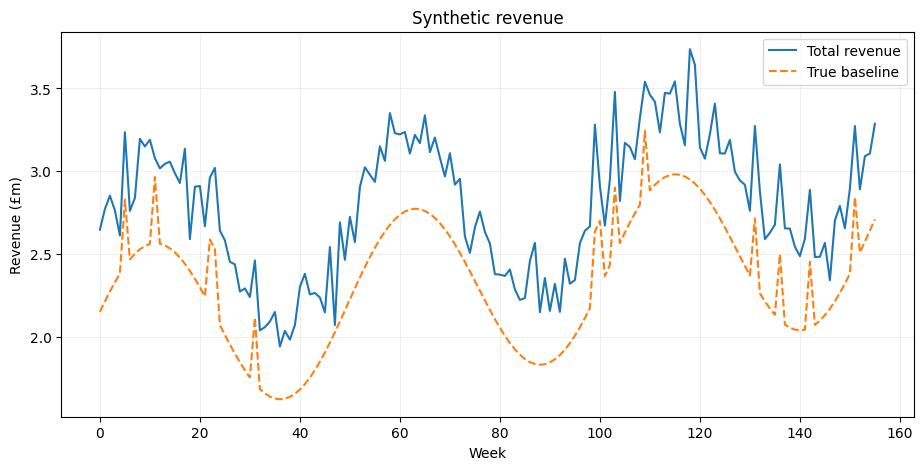

In [6]:

plt.figure(figsize=(11, 5))

plt.plot(
    clean_df["week"],
    clean_df["revenue"] / 1_000_000,
    label="Total revenue",
)

plt.plot(
    clean_df["week"],
    clean_df["baseline"] / 1_000_000,
    linestyle="--",
    label="True baseline",
)

plt.title("Synthetic revenue")
plt.xlabel("Week")
plt.ylabel("Revenue (£m)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



## 4. Fit the simplest possible MMM

For this first experiment, use ordinary least squares.

Because the DGP is linear and we include the correct controls, the channel coefficients are directly interpretable as ROAS.

This is **not intended to be the final production MMM**.

It is a sanity check:

> If a correctly specified simple model cannot recover the clean synthetic truth, do not add Bayesian complexity yet.


In [7]:

def fit_model(df):
    features = [
        "meta_spend",
        "search_spend",
        "tv_spend",
        "trend",
        "sin52",
        "cos52",
        "promo",
    ]

    X = sm.add_constant(df[features])

    model = sm.OLS(
        df["revenue"],
        X,
    ).fit()

    return model


In [8]:

clean_model = fit_model(clean_df)

single_run = pd.DataFrame({
    "channel": ["meta", "search", "tv"],
    "true_roas": [
        TRUE_ROAS["meta"],
        TRUE_ROAS["search"],
        TRUE_ROAS["tv"],
    ],
    "estimated_roas": [
        clean_model.params["meta_spend"],
        clean_model.params["search_spend"],
        clean_model.params["tv_spend"],
    ],
})

single_run["relative_error"] = (
    abs(
        single_run["estimated_roas"]
        - single_run["true_roas"]
    )
    / single_run["true_roas"]
)

print("R²:", round(clean_model.rsquared, 3))
display(single_run)


R²: 0.976


,channel,true_roas,estimated_roas,relative_error
0,meta,2.000,1.876,0.062
1,search,5.000,5.218,0.044
2,tv,1.500,1.599,0.066



## 5. Do not trust one simulation

One synthetic dataset can be lucky or unlucky.

So we repeatedly generate new datasets from the **same DGP** and measure how often the model recovers the known truth.

This is the Monte Carlo part of the experiment.


In [9]:

def run_one_simulation(
    rho,
    seed,
):
    df = generate_data(
        rho=rho,
        seed=seed,
    )

    model = fit_model(df)

    actual_corr = df[
        ["meta_spend", "search_spend"]
    ].corr().iloc[0, 1]

    rows = []

    channel_to_column = {
        "meta": "meta_spend",
        "search": "search_spend",
        "tv": "tv_spend",
    }

    for channel, column in channel_to_column.items():

        estimate = model.params[column]

        ci_low, ci_high = (
            model
            .conf_int(alpha=0.10)
            .loc[column]
        )

        true_roas = TRUE_ROAS[channel]

        rows.append({
            "rho_target": rho,
            "actual_correlation": actual_corr,
            "seed": seed,
            "channel": channel,
            "true_roas": true_roas,
            "estimated_roas": estimate,
            "relative_error": (
                abs(estimate - true_roas)
                / true_roas
            ),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "covered_truth": (
                ci_low
                <= true_roas
                <= ci_high
            ),
            "r2": model.rsquared,
        })

    return rows



## 6. Clean-case Monte Carlo

Run 500 clean simulations first.

This answers:

> Is the clean setup sufficiently informative before we introduce multicollinearity?


In [10]:

clean_rows = []

N_CLEAN_SIMS = 500

for simulation_id in range(N_CLEAN_SIMS):

    clean_rows.extend(
        run_one_simulation(
            rho=0.20,
            seed=10_000 + simulation_id,
        )
    )

clean_results = pd.DataFrame(clean_rows)

clean_scorecard = (
    clean_results
    .groupby("channel")
    .agg(
        true_roas=("true_roas", "first"),
        mean_estimated_roas=("estimated_roas", "mean"),
        median_estimated_roas=("estimated_roas", "median"),
        median_relative_error=("relative_error", "median"),
        probability_over_50pct_error=(
            "relative_error",
            lambda x: (x > 0.50).mean(),
        ),
        coverage_90pct=("covered_truth", "mean"),
        mean_r2=("r2", "mean"),
    )
)

display(clean_scorecard)


,true_roas,mean_estimated_roas,median_estimated_roas,median_relative_error,probability_over_50pct_error,coverage_90pct,mean_r2
channel,,,,,,,
meta,2.000,2.021,2.027,0.081,0.000,0.878,0.980
search,5.000,4.972,4.981,0.041,0.000,0.910,0.980
tv,1.500,1.502,1.506,0.051,0.000,0.890,0.980



### What we want to see

The exact thresholds are not sacred, but a healthy clean case should roughly show:

- estimates centred near the true ROAS
- low median relative error
- low probability of very large error
- ~90% coverage for a 90% confidence interval
- TV behaving stably as an independent control

If this looks sensible, move on.

---

## 7. The actual stress test

Now change only one thing:

> **Meta/Search spend correlation**

Everything else stays the same.

Run:

\[
0.20 \rightarrow 0.50 \rightarrow 0.70 \rightarrow 0.90 \rightarrow 0.95 \rightarrow 0.98
\]


In [12]:

N_STRESS_SIMS = 300

all_rows = []

for rho in CORRELATION_LEVELS:

    for simulation_id in range(N_STRESS_SIMS):

        seed = (
            100_000
            + int(rho * 10_000) * 1_000
            + simulation_id
        )

        all_rows.extend(
            run_one_simulation(
                rho=rho,
                seed=seed,
            )
        )

stress_results = pd.DataFrame(all_rows)

print(
    f"Finished {len(CORRELATION_LEVELS) * N_STRESS_SIMS:,} datasets"
)


Finished 1,800 datasets



## 8. Summarise the result

For each channel and correlation level, calculate:

- median estimated ROAS
- median relative error
- probability of >50% error
- 90% interval coverage
- average R²


In [13]:

stress_summary = (
    stress_results
    .groupby(
        ["rho_target", "channel"]
    )
    .agg(
        actual_correlation=(
            "actual_correlation",
            "mean",
        ),
        true_roas=(
            "true_roas",
            "first",
        ),
        median_estimated_roas=(
            "estimated_roas",
            "median",
        ),
        median_relative_error=(
            "relative_error",
            "median",
        ),
        probability_over_50pct_error=(
            "relative_error",
            lambda x: (x > 0.50).mean(),
        ),
        coverage_90pct=(
            "covered_truth",
            "mean",
        ),
        mean_r2=(
            "r2",
            "mean",
        ),
    )
    .reset_index()
)

stress_summary["median_relative_error_pct"] = (
    100
    * stress_summary["median_relative_error"]
)

stress_summary["probability_over_50pct_error_pct"] = (
    100
    * stress_summary["probability_over_50pct_error"]
)

display(
    stress_summary[
        [
            "rho_target",
            "channel",
            "actual_correlation",
            "true_roas",
            "median_estimated_roas",
            "median_relative_error_pct",
            "probability_over_50pct_error_pct",
            "coverage_90pct",
            "mean_r2",
        ]
    ]
)


,rho_target,channel,actual_correlation,true_roas,median_estimated_roas,median_relative_error_pct,probability_over_50pct_error_pct,coverage_90pct,mean_r2
0,0.200,meta,0.198,2.000,2.028,7.764,0.000,0.910,0.980
1,0.200,search,0.198,5.000,4.981,4.280,0.000,0.900,0.980
2,0.200,tv,0.198,1.500,1.500,4.858,0.000,0.910,0.980
3,0.500,meta,0.498,2.000,2.017,9.848,0.000,0.877,0.980
4,0.500,search,0.498,5.000,4.989,4.784,0.000,0.887,0.980
5,0.500,tv,0.498,1.500,1.505,5.092,0.000,0.920,0.980
6,0.700,meta,0.702,2.000,2.014,11.141,0.333,0.893,0.980
7,0.700,search,0.702,5.000,4.978,5.080,0.000,0.903,0.980
8,0.700,tv,0.702,1.500,1.513,4.717,0.000,0.910,0.980
9,0.900,meta,0.897,2.000,2.005,17.116,7.333,0.900,0.980



## 9. Main chart — attribution reliability

This is the most useful public-facing chart.

If multicollinearity is damaging channel-level identification, the probability of a large ROAS error should rise for **Meta and Search** as their correlation approaches 1.

TV should remain comparatively stable because it was not made correlated with them.


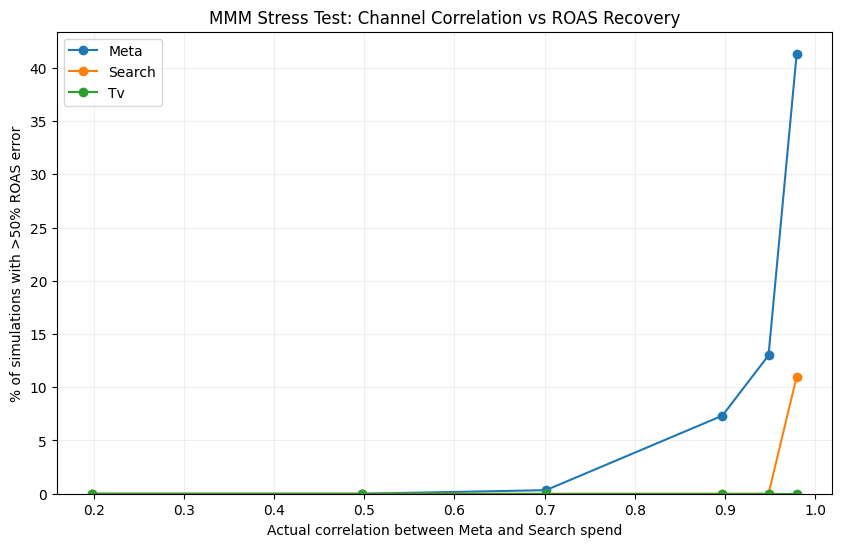

In [14]:

plt.figure(figsize=(10, 6))

for channel in [
    "meta",
    "search",
    "tv",
]:
    plot_df = (
        stress_summary[
            stress_summary["channel"] == channel
        ]
        .sort_values("actual_correlation")
    )

    plt.plot(
        plot_df["actual_correlation"],
        plot_df["probability_over_50pct_error_pct"],
        marker="o",
        label=channel.title(),
    )

plt.title(
    "MMM Stress Test: Channel Correlation vs ROAS Recovery"
)
plt.xlabel(
    "Actual correlation between Meta and Search spend"
)
plt.ylabel(
    "% of simulations with >50% ROAS error"
)
plt.ylim(bottom=0)
plt.legend()
plt.grid(alpha=0.2)
plt.show()



## 10. Compare model fit

Now check whether overall model fit deteriorates at the same rate.

This is the important distinction:

> **Prediction quality and channel attribution quality are not the same thing.**


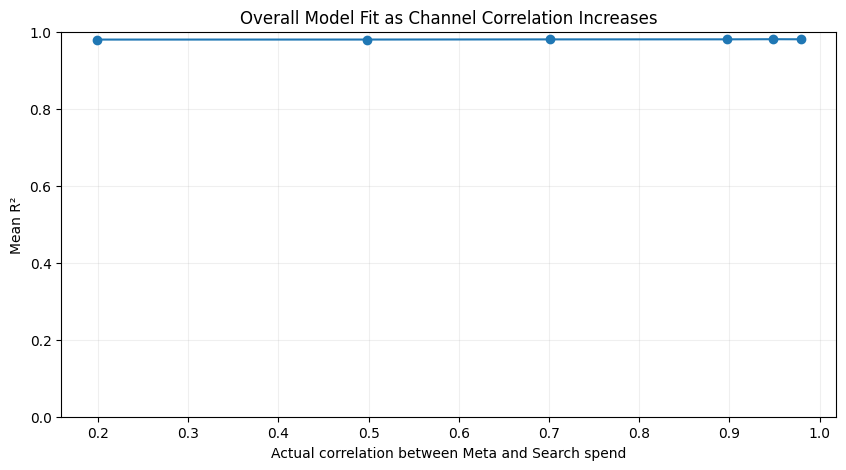

,rho_target,actual_correlation,mean_r2
0,0.200,0.198,0.980
1,0.500,0.498,0.980
2,0.700,0.702,0.980
3,0.900,0.897,0.980
4,0.950,0.948,0.981
5,0.980,0.980,0.980


In [15]:

fit_summary = (
    stress_results
    .groupby("rho_target")
    .agg(
        actual_correlation=(
            "actual_correlation",
            "mean",
        ),
        mean_r2=(
            "r2",
            "mean",
        ),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    fit_summary["actual_correlation"],
    fit_summary["mean_r2"],
    marker="o",
)

plt.title(
    "Overall Model Fit as Channel Correlation Increases"
)
plt.xlabel(
    "Actual correlation between Meta and Search spend"
)
plt.ylabel("Mean R²")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.show()

display(fit_summary)



## 11. Look directly at ROAS uncertainty

The median estimate may remain near the truth across repeated simulations even while individual model runs become much less reliable.

That is why it is useful to inspect the distribution rather than only the mean.


In [16]:

roas_distribution_summary = (
    stress_results
    .groupby(
        ["rho_target", "channel"]
    )
    ["estimated_roas"]
    .agg(
        median="median",
        p10=lambda x: np.quantile(x, 0.10),
        p90=lambda x: np.quantile(x, 0.90),
    )
    .reset_index()
)

display(roas_distribution_summary)


,rho_target,channel,median,p10,p90
0,0.200,meta,2.028,1.697,2.318
1,0.200,search,4.981,4.586,5.430
2,0.200,tv,1.500,1.362,1.634
3,0.500,meta,2.017,1.651,2.373
4,0.500,search,4.989,4.551,5.484
5,0.500,tv,1.505,1.359,1.643
6,0.700,meta,2.014,1.604,2.435
7,0.700,search,4.978,4.433,5.524
8,0.700,tv,1.513,1.364,1.633
9,0.900,meta,2.005,1.366,2.673


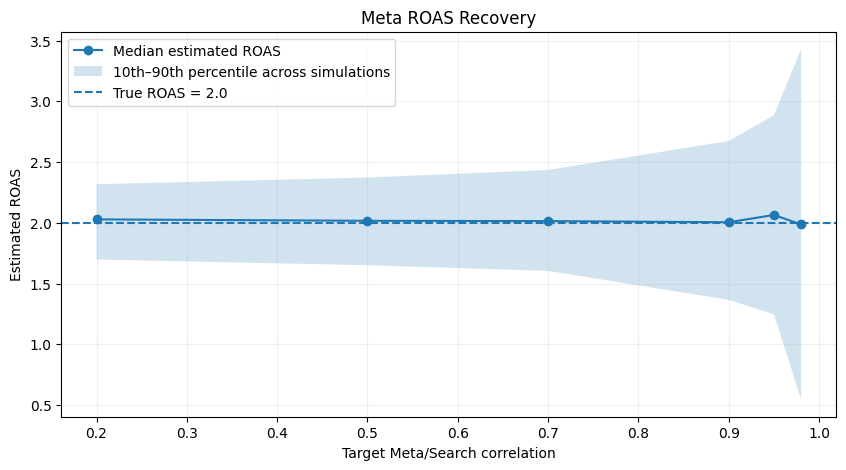

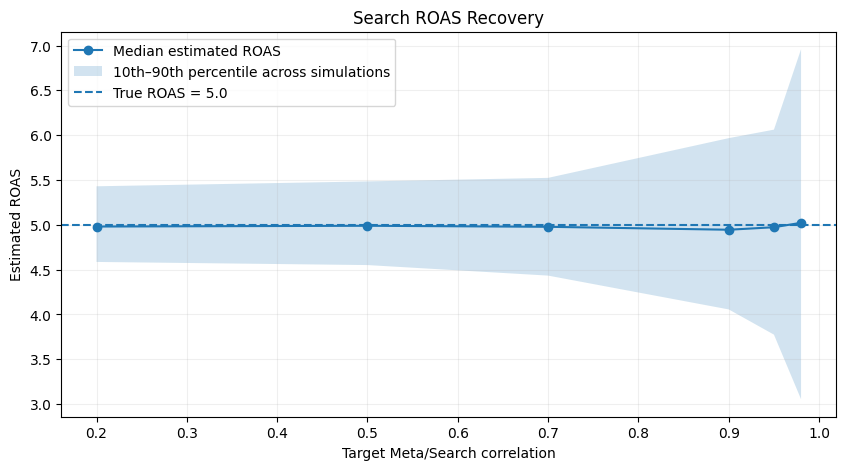

In [17]:

for channel in ["meta", "search"]:

    plot_df = (
        roas_distribution_summary[
            roas_distribution_summary["channel"]
            == channel
        ]
        .sort_values("rho_target")
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        plot_df["rho_target"],
        plot_df["median"],
        marker="o",
        label="Median estimated ROAS",
    )

    plt.fill_between(
        plot_df["rho_target"],
        plot_df["p10"],
        plot_df["p90"],
        alpha=0.2,
        label="10th–90th percentile across simulations",
    )

    plt.axhline(
        TRUE_ROAS[channel],
        linestyle="--",
        label=f"True ROAS = {TRUE_ROAS[channel]}",
    )

    plt.title(
        f"{channel.title()} ROAS Recovery"
    )
    plt.xlabel(
        "Target Meta/Search correlation"
    )
    plt.ylabel("Estimated ROAS")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


In [18]:

stress_results.to_csv(
    "mmm_stress_test_01_raw_results.csv",
    index=False,
)

stress_summary.to_csv(
    "mmm_stress_test_01_summary.csv",
    index=False,
)

print("Saved:")
print(" - mmm_stress_test_01_raw_results.csv")
print(" - mmm_stress_test_01_summary.csv")


Saved:
 - mmm_stress_test_01_raw_results.csv
 - mmm_stress_test_01_summary.csv



# 12. Stop here

Do **not** add adstock, saturation, priors and endogeneity to this notebook.

First understand this result.

Then create a second notebook for the next stress test.

Recommended progression:

1. **This notebook:** multicollinearity
2. Always-on / low-variation media
3. Prior sensitivity using Meridian
4. Endogeneity
5. Low media signal
6. Adstock
7. Saturation
8. Combined realistic scenario

When you are ready to move to Meridian, keep the **same data-generating process** and replace only the fitting stage.

That gives you a clean bridge from:

> simple statistical identification test

to:

> full Bayesian MMM stress test
